In [2]:
# Celda 1: instalar todo
!pip install transformers sentencepiece torch -q

from transformers import pipeline, MarianMTModel, MarianTokenizer
import pandas as pd
import sqlite3

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta = '/content/drive/MyDrive/Proyecto2/'  # ← ajusta esto

df_en = pd.read_csv(ruta + 'movie_reviews_eng.csv')
df_fr = pd.read_csv(ruta + 'movie_reviews_fr.csv')
df_sp = pd.read_csv(ruta + 'movie_reviews_sp.csv')

# Verificar que cargaron bien
print("Inglés:",  df_en.shape)   # debe ser (10, 4)
print("Francés:", df_fr.shape)   # debe ser (10, 4)
print("Español:", df_sp.shape)   # debe ser (10, 4)

Inglés: (10, 4)
Francés: (10, 4)
Español: (10, 4)


In [5]:
# Renombrar columnas al estándar inglés
# (el CSV inglés viene con 'Movie / TV Series' en vez de 'Title')
df_en.columns = ['Title', 'Year', 'Synopsis', 'Review']
df_fr.columns = ['Title', 'Year', 'Synopsis', 'Review']
df_sp.columns = ['Title', 'Year', 'Synopsis', 'Review']

# Etiquetar idioma original de cada fila
df_en['Original_Language'] = 'English'
df_fr['Original_Language'] = 'French'
df_sp['Original_Language'] = 'Spanish'

# Unir los 3 en un solo DataFrame
df = pd.concat([df_en, df_fr, df_sp], ignore_index=True)

# Verificar resultado final
print("Total filas:", df.shape[0])        # debe ser 30
print("Columnas:", df.columns.tolist())   # 5 columnas
df.head(3)

Total filas: 30
Columnas: ['Title', 'Year', 'Synopsis', 'Review', 'Original_Language']


,Title,Year,Synopsis,Review,Original_Language
0,The Shawshank Redemption,1994,"Andy Dufresne (Tim Robbins), a successful bank...","""The Shawshank Redemption is an inspiring tale...",English
1,The Dark Knight,2008,Batman (Christian Bale) teams up with District...,"""The Dark Knight is a thrilling and intense su...",English
2,Forrest Gump,1994,Forrest Gump (Tom Hanks) is a simple man with ...,"""Forrest Gump is a heartwarming and inspiratio...",English


In [6]:
from transformers import MarianMTModel, MarianTokenizer

# Cargar francés → inglés
model_name_fr = "Helsinki-NLP/opus-mt-fr-en"
tokenizer_fr = MarianTokenizer.from_pretrained(model_name_fr)
model_fr = MarianMTModel.from_pretrained(model_name_fr)

# Cargar español → inglés
model_name_es = "Helsinki-NLP/opus-mt-es-en"
tokenizer_es = MarianTokenizer.from_pretrained(model_name_es)
model_es = MarianMTModel.from_pretrained(model_name_es)

print("Traductores listos ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Traductores listos ✅


In [7]:
def translate_text(text, tokenizer, model):
    if pd.isna(text) or str(text).strip() == '':
        return text
    inputs = tokenizer(str(text)[:512], return_tensors="pt", padding=True, truncation=True)
    translated = model.generate(**inputs)
    return tokenizer.decode(translated[0], skip_special_tokens=True)

In [8]:
for idx, row in df.iterrows():
    if row['Original_Language'] == 'French':
        print(f"Traduciendo fila {idx} (FR)...")
        df.at[idx, 'Synopsis'] = translate_text(row['Synopsis'], tokenizer_fr, model_fr)
        df.at[idx, 'Review']   = translate_text(row['Review'],   tokenizer_fr, model_fr)

    elif row['Original_Language'] == 'Spanish':
        print(f"Traduciendo fila {idx} (ES)...")
        df.at[idx, 'Synopsis'] = translate_text(row['Synopsis'], tokenizer_es, model_es)
        df.at[idx, 'Review']   = translate_text(row['Review'],   tokenizer_es, model_es)

print("\n¡Traducción completada! ✅")

Traduciendo fila 10 (FR)...
Traduciendo fila 11 (FR)...
Traduciendo fila 12 (FR)...
Traduciendo fila 13 (FR)...
Traduciendo fila 14 (FR)...
Traduciendo fila 15 (FR)...
Traduciendo fila 16 (FR)...
Traduciendo fila 17 (FR)...
Traduciendo fila 18 (FR)...
Traduciendo fila 19 (FR)...
Traduciendo fila 20 (ES)...
Traduciendo fila 21 (ES)...
Traduciendo fila 22 (ES)...
Traduciendo fila 23 (ES)...
Traduciendo fila 24 (ES)...
Traduciendo fila 25 (ES)...
Traduciendo fila 26 (ES)...
Traduciendo fila 27 (ES)...
Traduciendo fila 28 (ES)...
Traduciendo fila 29 (ES)...

¡Traducción completada! ✅


In [9]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("Modelo de sentimiento listo ✅")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Modelo de sentimiento listo ✅


In [10]:
def get_sentiment(text):
    if pd.isna(text) or str(text).strip() == '':
        return 'UNKNOWN'
    result = sentiment_model(str(text)[:512])
    return result[0]['label']  # devuelve POSITIVE o NEGATIVE

df['Sentiment'] = df['Review'].apply(get_sentiment)
print("Sentimiento aplicado ✅")
print(df['Sentiment'].value_counts())

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Sentimiento aplicado ✅
Sentiment
POSITIVE    15
NEGATIVE    15
Name: count, dtype: int64


In [11]:
df[['Title', 'Original_Language', 'Sentiment']]

,Title,Original_Language,Sentiment
0,The Shawshank Redemption,English,POSITIVE
1,The Dark Knight,English,POSITIVE
2,Forrest Gump,English,POSITIVE
3,The Godfather,English,POSITIVE
4,Inception,English,POSITIVE
5,Blade Runner 2049,English,NEGATIVE
6,Scott Pilgrim vs. the World,English,NEGATIVE
7,The Nice Guys,English,NEGATIVE
8,Solo: A Star Wars Story,English,NEGATIVE
9,The Island,English,NEGATIVE


In [12]:
# Seleccionar solo las columnas que pide el proyecto
columnas_finales = ['Title', 'Year', 'Synopsis', 'Review', 'Original_Language', 'Sentiment']
df_final = df[columnas_finales]

# Guardar el CSV en Drive
df_final.to_csv(ruta + 'reviews_with_sentiment.csv', index=False)
print("CSV guardado ✅")
print(f"Filas: {df_final.shape[0]} | Columnas: {df_final.shape[1]}")

CSV guardado ✅
Filas: 30 | Columnas: 6


In [13]:
# Crear la base de datos y guardar el DataFrame
conn = sqlite3.connect(ruta + 'reviews.db')
df_final.to_sql('reviews', conn, if_exists='replace', index=False)
conn.close()

print("Base de datos SQLite guardada ✅")

Base de datos SQLite guardada ✅


In [14]:
# Distribución general
print("=== RENDIMIENTO DEL MODELO ===\n")
print("Distribución de sentimientos:")
print(df_final['Sentiment'].value_counts())
print(f"\nTotal reseñas procesadas: {len(df_final)}")

# Distribución por idioma
print("\nSentimiento por idioma original:")
print(df_final.groupby('Original_Language')['Sentiment'].value_counts())

# Porcentaje
total = len(df_final)
positivos = (df_final['Sentiment'] == 'POSITIVE').sum()
negativos = (df_final['Sentiment'] == 'NEGATIVE').sum()
print(f"\nPOSITIVE: {positivos} ({positivos/total*100:.1f}%)")
print(f"NEGATIVE: {negativos} ({negativos/total*100:.1f}%)")

=== RENDIMIENTO DEL MODELO ===

Distribución de sentimientos:
Sentiment
POSITIVE    15
NEGATIVE    15
Name: count, dtype: int64

Total reseñas procesadas: 30

Sentimiento por idioma original:
Original_Language  Sentiment
English            NEGATIVE     5
                   POSITIVE     5
French             NEGATIVE     5
                   POSITIVE     5
Spanish            NEGATIVE     5
                   POSITIVE     5
Name: count, dtype: int64

POSITIVE: 15 (50.0%)
NEGATIVE: 15 (50.0%)


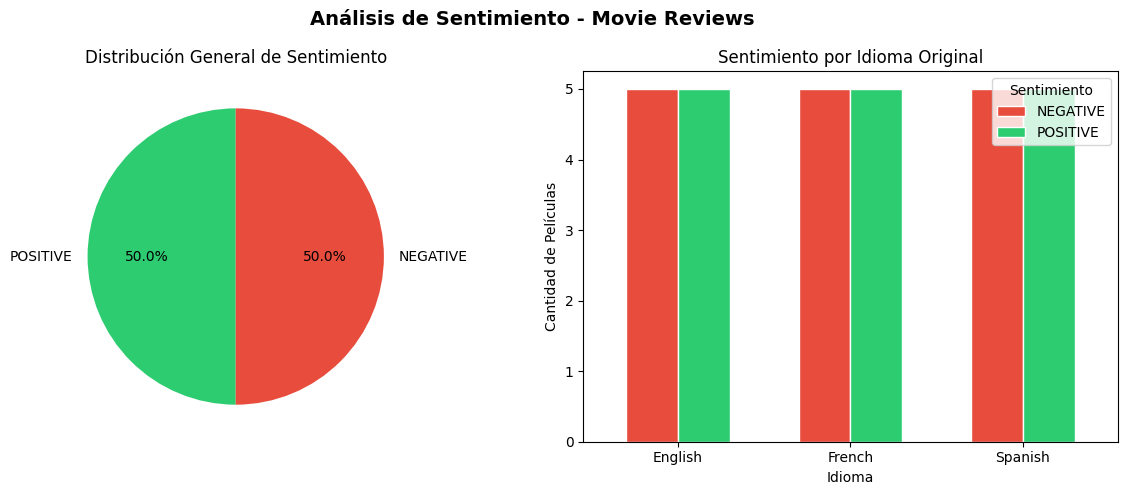

Gráfico guardado ✅


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Análisis de Sentimiento - Movie Reviews', fontsize=14, fontweight='bold')

# Gráfico 1 — Distribución general (pie chart)
sentiment_counts = df_final['Sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Distribución General de Sentimiento')

# Gráfico 2 — Por idioma (bar chart)
sentiment_by_lang = df_final.groupby(['Original_Language', 'Sentiment']).size().unstack(fill_value=0)
sentiment_by_lang.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
                       edgecolor='white', width=0.6)
axes[1].set_title('Sentimiento por Idioma Original')
axes[1].set_xlabel('Idioma')
axes[1].set_ylabel('Cantidad de Películas')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentimiento')

plt.tight_layout()
plt.savefig(ruta + 'sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado ✅")

In [15]:
# Leer el CSV recién creado para confirmar que quedó bien
df_verificacion = pd.read_csv(ruta + 'reviews_with_sentiment.csv')
print(f"Filas: {df_verificacion.shape[0]}")
print(f"Columnas: {df_verificacion.columns.tolist()}")
df_verificacion.head(3)

Filas: 30
Columnas: ['Title', 'Year', 'Synopsis', 'Review', 'Original_Language', 'Sentiment']


,Title,Year,Synopsis,Review,Original_Language,Sentiment
0,The Shawshank Redemption,1994,"Andy Dufresne (Tim Robbins), a successful bank...","""The Shawshank Redemption is an inspiring tale...",English,POSITIVE
1,The Dark Knight,2008,Batman (Christian Bale) teams up with District...,"""The Dark Knight is a thrilling and intense su...",English,POSITIVE
2,Forrest Gump,1994,Forrest Gump (Tom Hanks) is a simple man with ...,"""Forrest Gump is a heartwarming and inspiratio...",English,POSITIVE
